In [51]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Transformer
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D
#import numpy as np


In [66]:
df = pd.read_csv('C:/Users/LHansen/prvt_cors_data/Elliot_Sinclair_prvt_CORS.csv')

print(df.head())

        date  code       ref         lon        lat       hgt
0  1/1 - 1/7  ESBR  NZGD2000  172.701722 -43.538302   11.0632
1  1/1 - 1/7  ESGM  NZGD2000  171.186842 -42.471965   14.2795
2  1/1 - 1/7  ESKV  NZGD2000  172.826170 -43.095774  299.4378
3  1/1 - 1/7  ESNL  NZGD2000  173.214055 -41.322193   14.0242
4  1/1 - 1/7  ESPM  NZGD2000  169.247210 -44.959487  220.2582


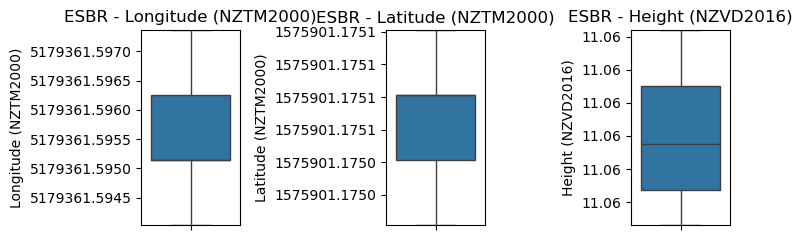

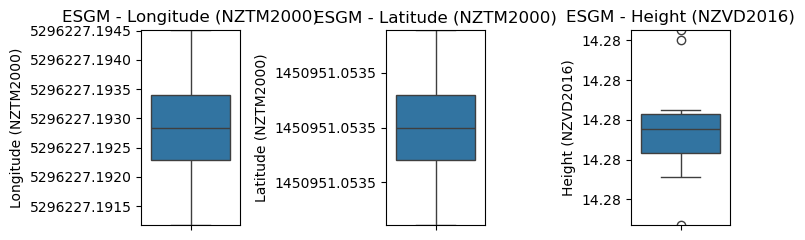

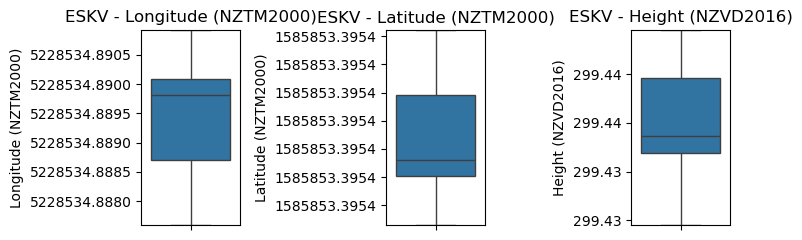

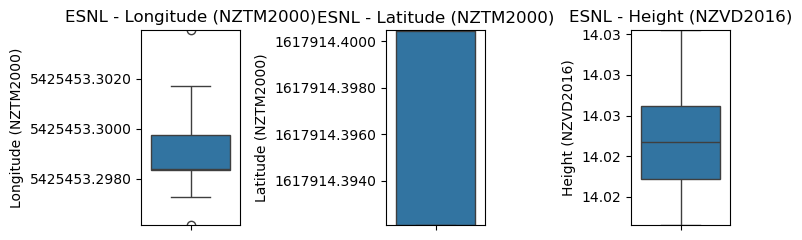

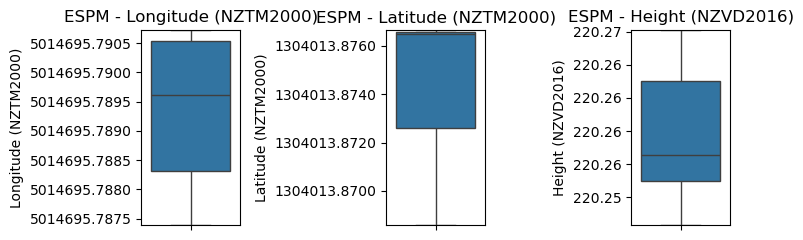

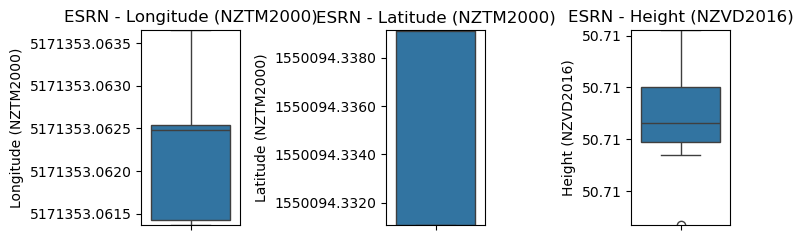

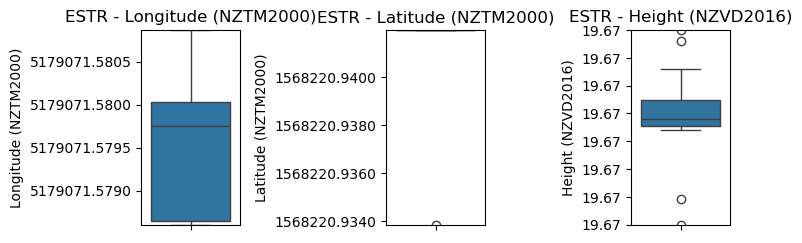

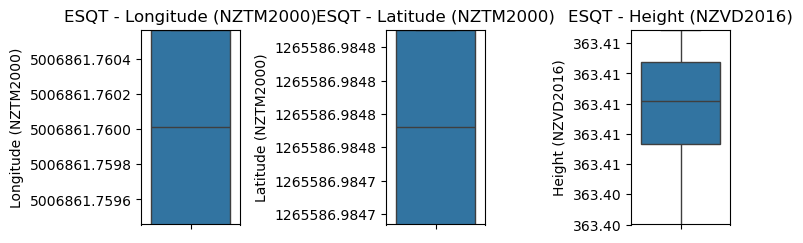

In [67]:


# Strip any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Ensure 'lon' and 'lat' columns exist
if 'lon' not in df.columns or 'lat' not in df.columns:
    raise KeyError("The DataFrame does not contain 'lon' and 'lat' columns.")

# Initialize the transformer for NZGD2000 to NZTM2000
transformer = Transformer.from_crs("EPSG:4167", "EPSG:2193")

# Apply the transformation to the 'lon' and 'lat' columns, ignoring rows with missing values
df[['lon_nztm', 'lat_nztm']] = df.dropna(subset=['lon', 'lat']).apply(lambda row: transformer.transform(row['lat'], row['lon']), axis=1, result_type='expand')

# Filter out rows with missing values in 'hgt' column
df = df.dropna(subset=['hgt'])

# Get the unique codes
codes = df['code'].unique()

# Create a figure for each code
for code in codes:
    # Filter the DataFrame for the current code
    df_code = df[df['code'] == code]
    
    # Create a figure with scaled-down size
    plt.figure(figsize=(7.5, 2.5))  
    
    # Create a box plot for 'lon_nztm'
    plt.subplot(1, 3, 1)
    sns.boxplot(y=df_code['lon_nztm'])
    plt.title(f'{code} - Longitude (NZTM2000)')
    plt.ylabel('Longitude (NZTM2000)')
    plt.ylim(df_code['lon_nztm'].min(), df_code['lon_nztm'].max())  # Set y-axis limits specific to the code
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.4f'))  # Ensure real data values are shown with 4 decimal places
    
    # Create a box plot for 'lat_nztm'
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df_code['lat_nztm'])
    plt.title(f'{code} - Latitude (NZTM2000)')
    plt.ylabel('Latitude (NZTM2000)')
    plt.ylim(df_code['lat_nztm'].min(), df_code['lat_nztm'].max())  # Set y-axis limits specific to the code
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.4f'))  # Ensure real data values are shown with 4 decimal places
    
    # Create a box plot for 'hgt' referenced to NZVD2016
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df_code['hgt'])
    plt.title(f'{code} - Height (NZVD2016)')
    plt.ylabel('Height (NZVD2016)')
    plt.ylim(df_code['hgt'].min(), df_code['hgt'].max())  # Set y-axis limits specific to the code
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Ensure real data values are shown with 2 decimal places
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()


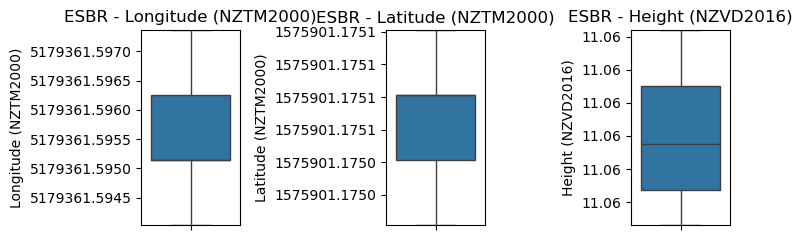

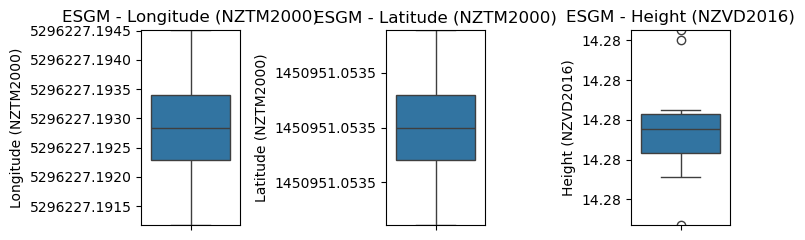

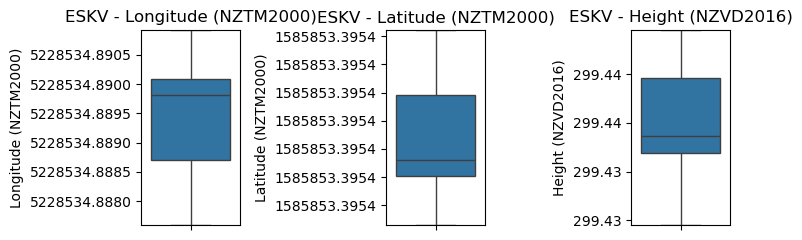

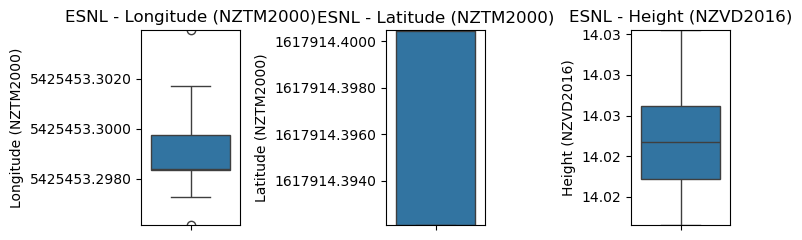

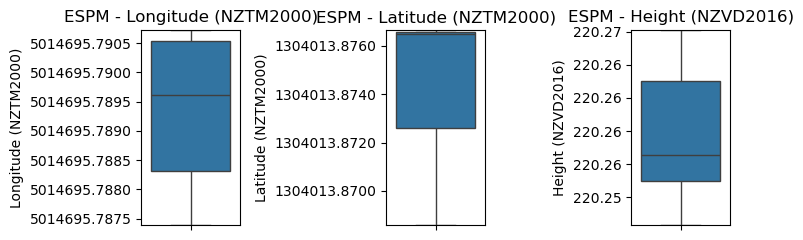

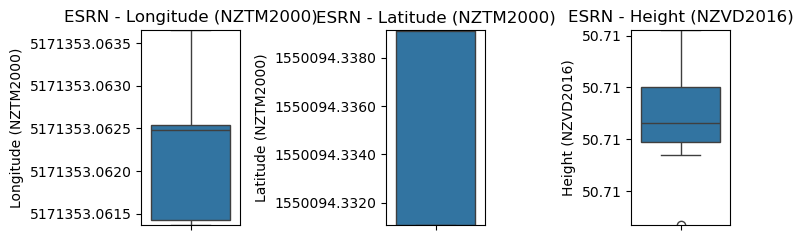

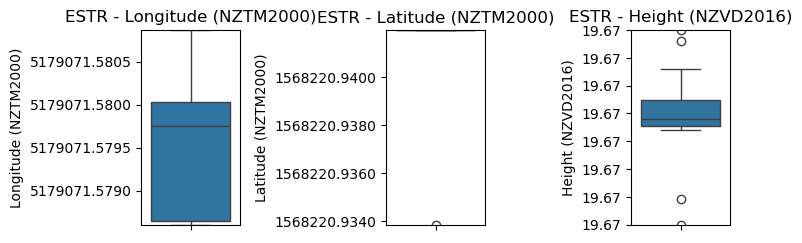

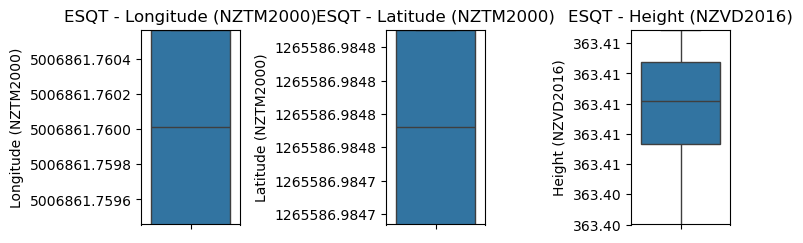

In [68]:


# Initialize the transformer for NZGD2000 to NZTM2000
transformer = Transformer.from_crs("EPSG:4167", "EPSG:2193")

# Apply the transformation to the 'lon' and 'lat' columns, ignoring rows with missing values
df[['lon_nztm', 'lat_nztm']] = df.dropna(subset=['lon', 'lat']).apply(lambda row: transformer.transform(row['lat'], row['lon']), axis=1, result_type='expand')

# Filter out rows with missing values in 'hgt' column
df = df.dropna(subset=['hgt'])

# Get the unique codes
codes = df['code'].unique()

# Create a figure for each code
for code in codes:
    # Filter the DataFrame for the current code
    df_code = df[df['code'] == code]
    
    # Create a figure with scaled-down size
    plt.figure(figsize=(7.5, 2.5))  
    
    # Create a box plot for 'lon_nztm'
    plt.subplot(1, 3, 1)
    sns.boxplot(y=df_code['lon_nztm'])
    plt.title(f'{code} - Longitude (NZTM2000)')
    plt.ylabel('Longitude (NZTM2000)')
    plt.ylim(df_code['lon_nztm'].min(), df_code['lon_nztm'].max())  # Set y-axis limits specific to the code
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.4f'))  # Ensure real data values are shown with 4 decimal places
    
    # Create a box plot for 'lat_nztm'
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df_code['lat_nztm'])
    plt.title(f'{code} - Latitude (NZTM2000)')
    plt.ylabel('Latitude (NZTM2000)')
    plt.ylim(df_code['lat_nztm'].min(), df_code['lat_nztm'].max())  # Set y-axis limits specific to the code
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.4f'))  # Ensure real data values are shown with 4 decimal places
    
    # Create a box plot for 'hgt' referenced to NZVD2016
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df_code['hgt'])
    plt.title(f'{code} - Height (NZVD2016)')
    plt.ylabel('Height (NZVD2016)')
    plt.ylim(df_code['hgt'].min(), df_code['hgt'].max())  # Set y-axis limits specific to the code
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Ensure real data values are shown with 2 decimal places
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()


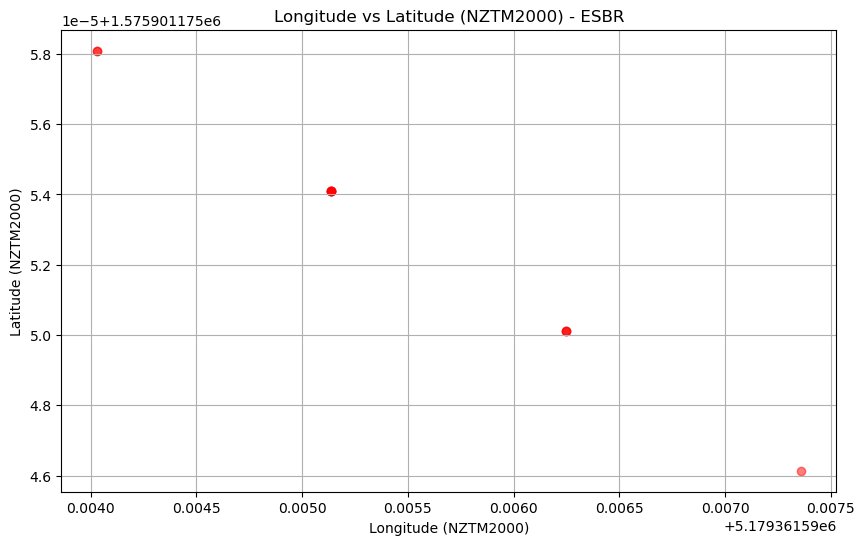

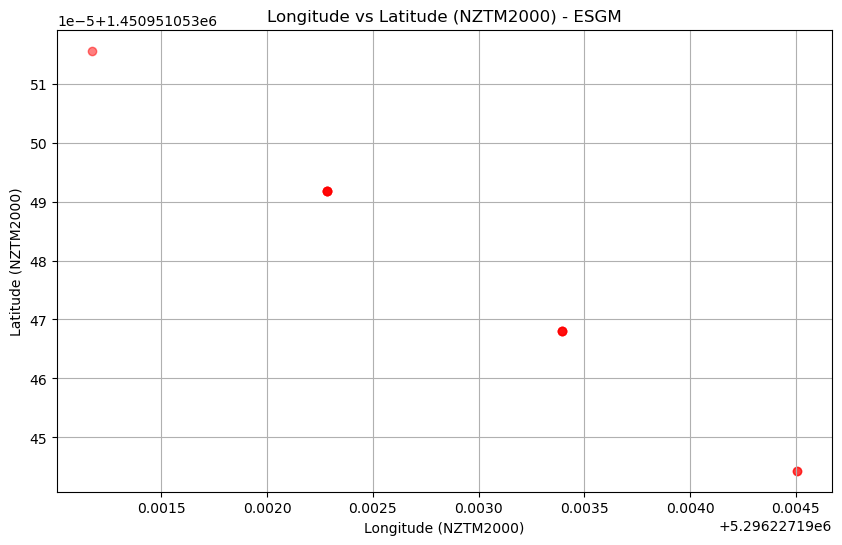

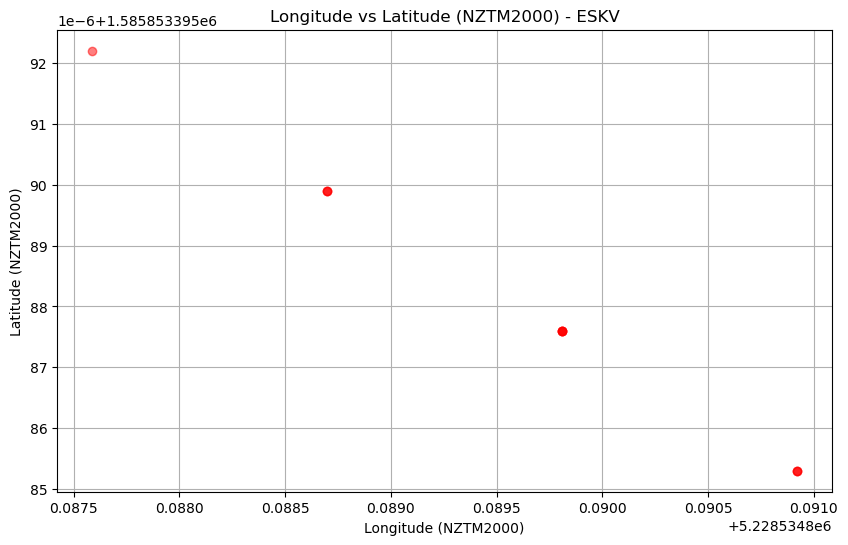

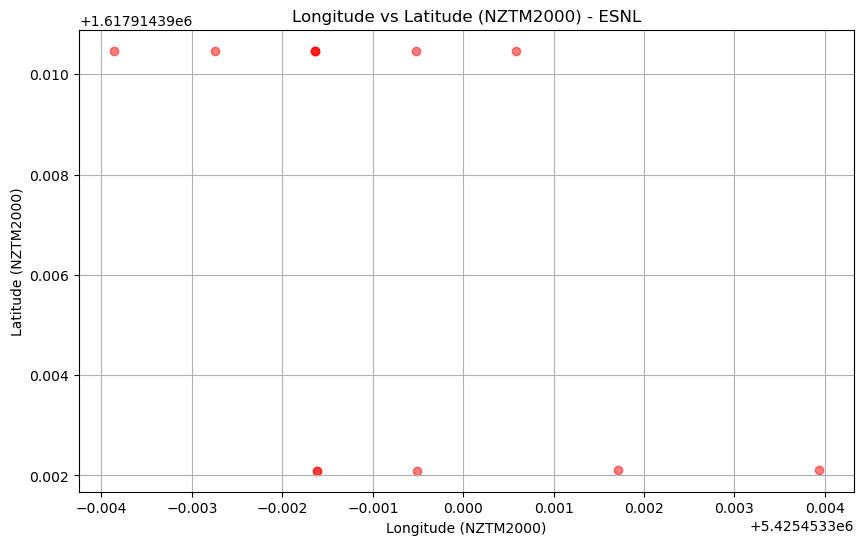

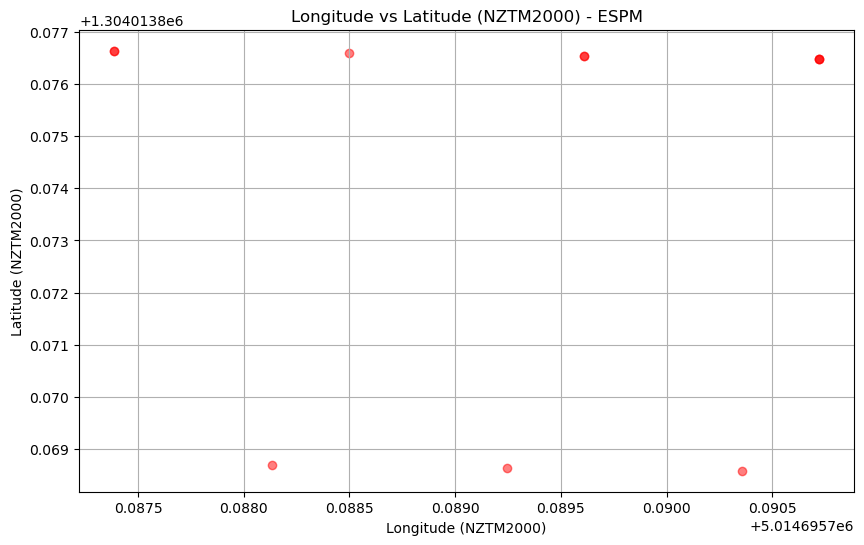

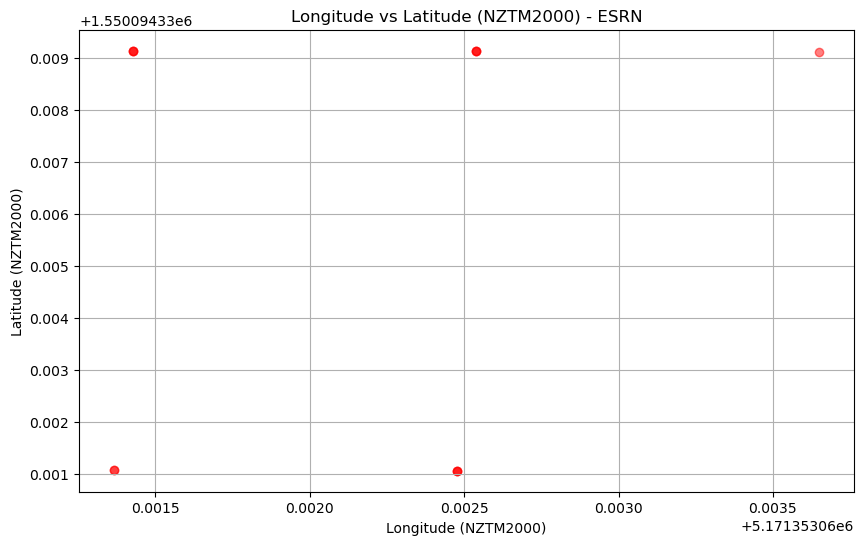

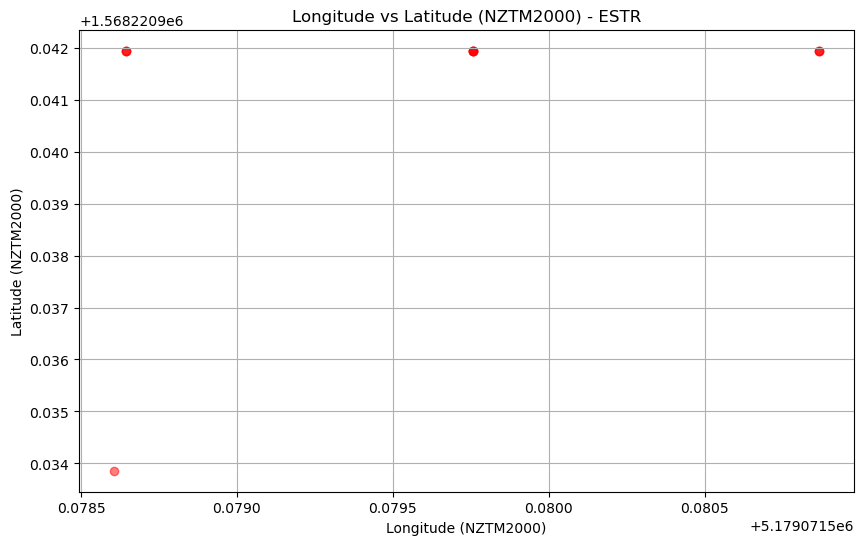

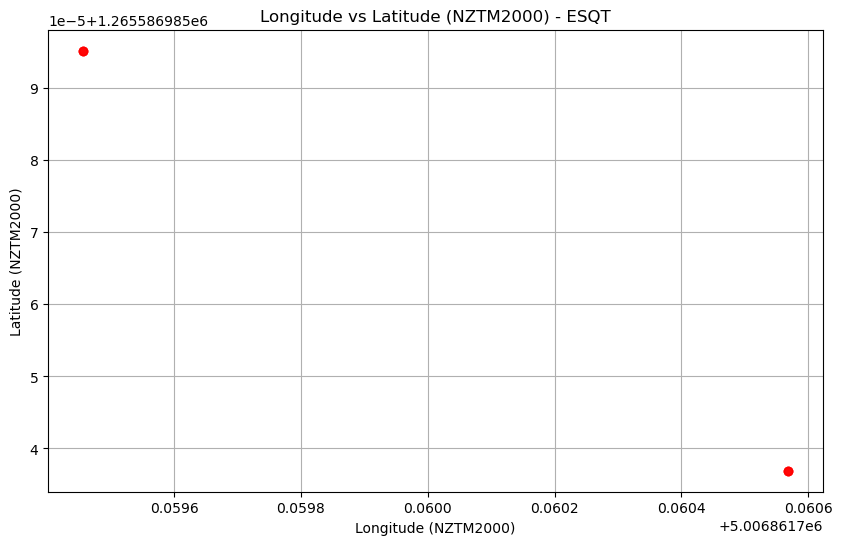

In [69]:
# Create a scatter plot of longitude vs latitude for each unique code
for code in codes:
    # Filter the DataFrame for the current code
    df_code = df[df['code'] == code]
    
    # Create a scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(df_code['lon_nztm'], df_code['lat_nztm'], c='red', alpha=0.5)
    plt.title(f'Longitude vs Latitude (NZTM2000) - {code}')
    plt.xlabel('Longitude (NZTM2000)')
    plt.ylabel('Latitude (NZTM2000)')
    plt.grid(True)
    plt.show()


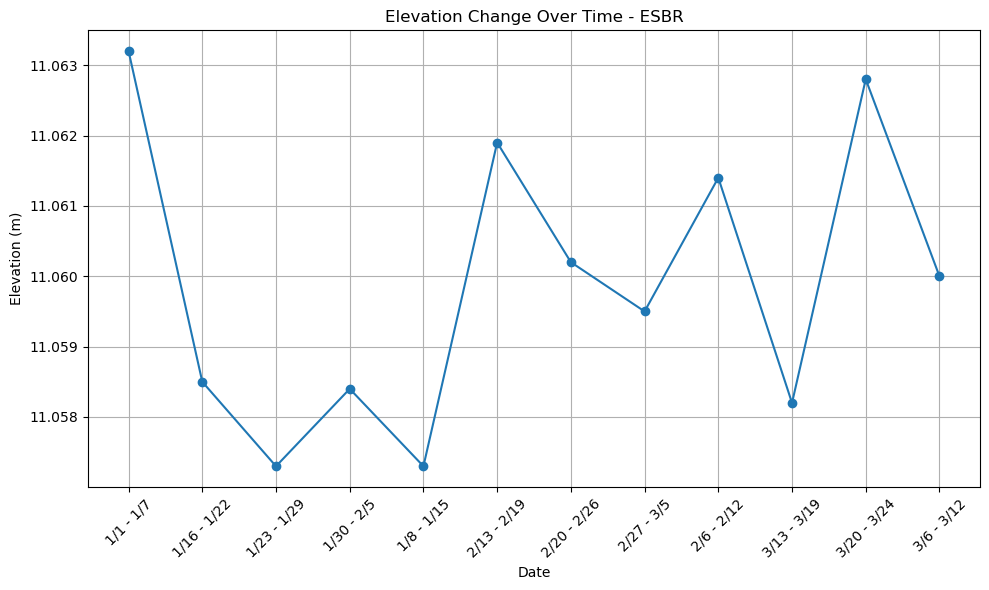

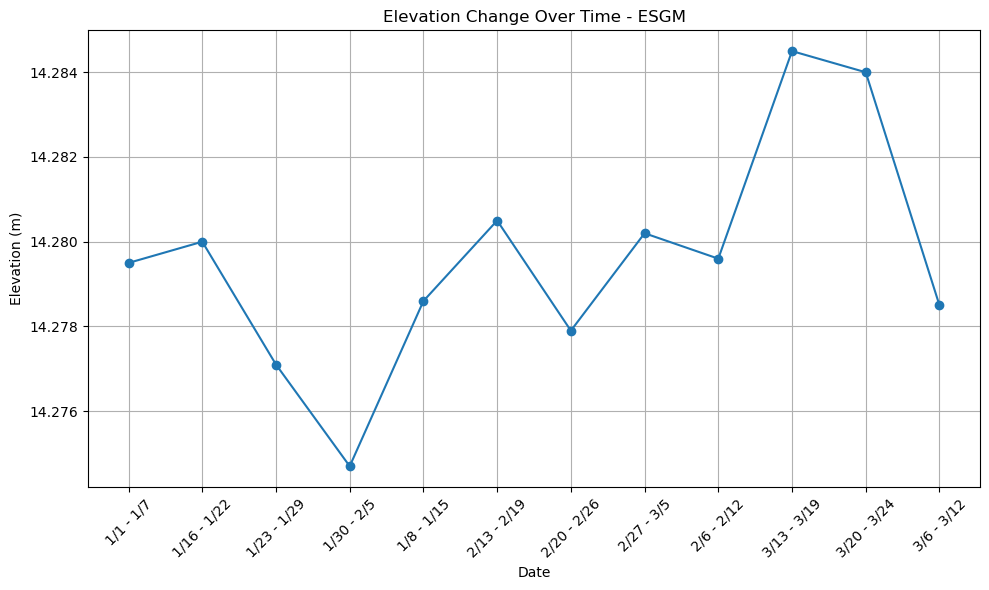

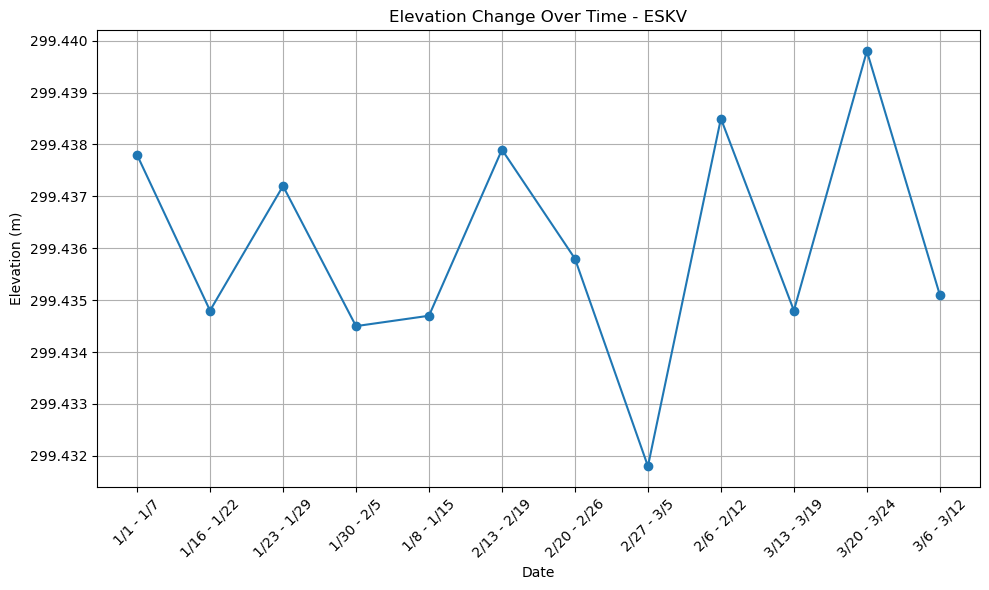

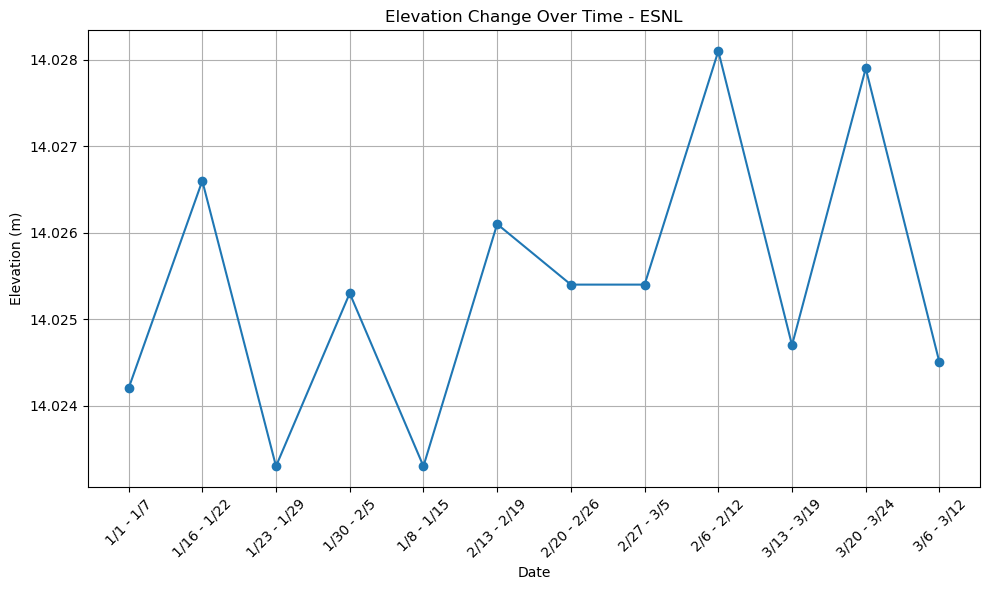

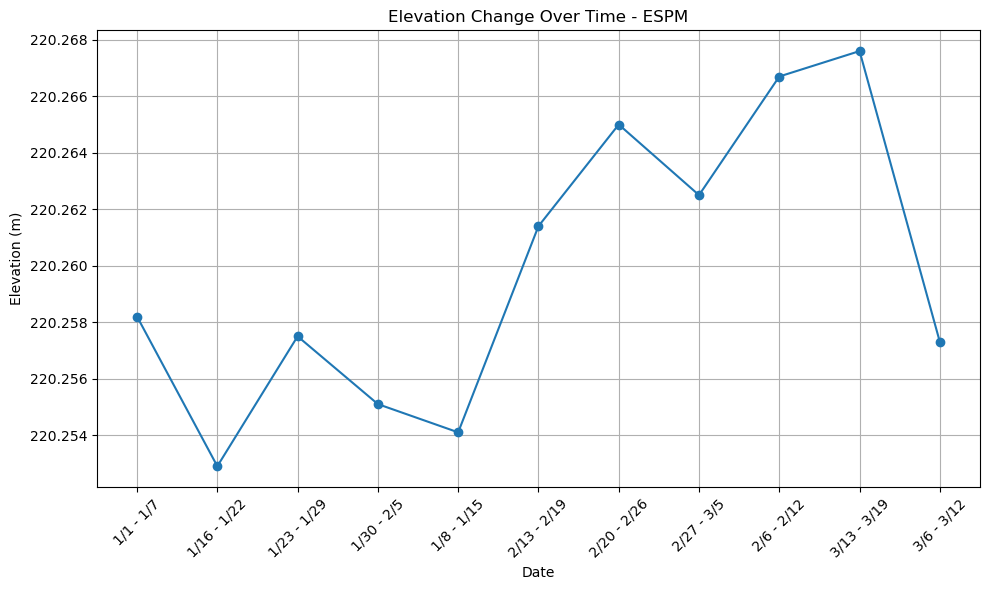

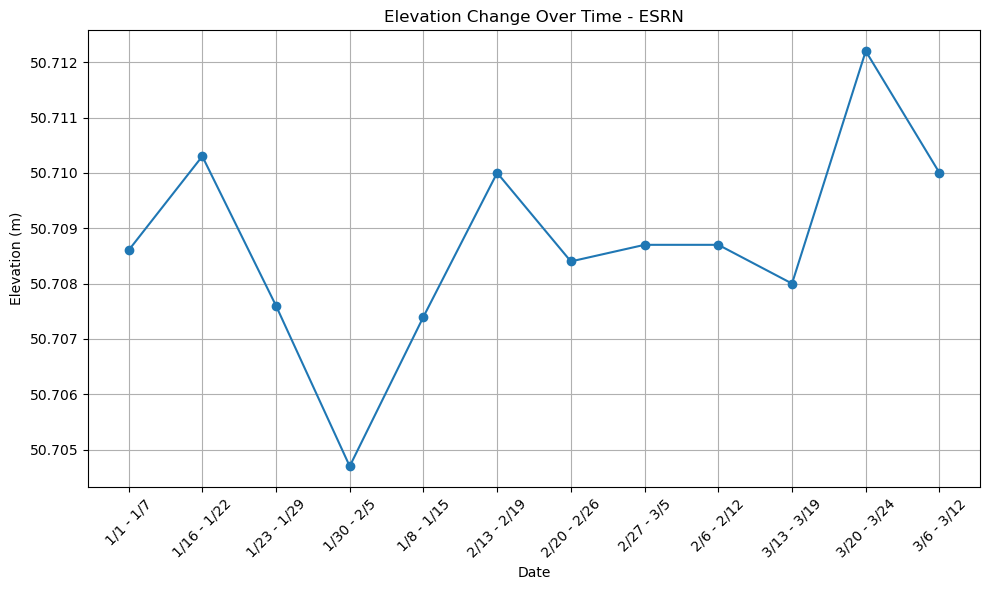

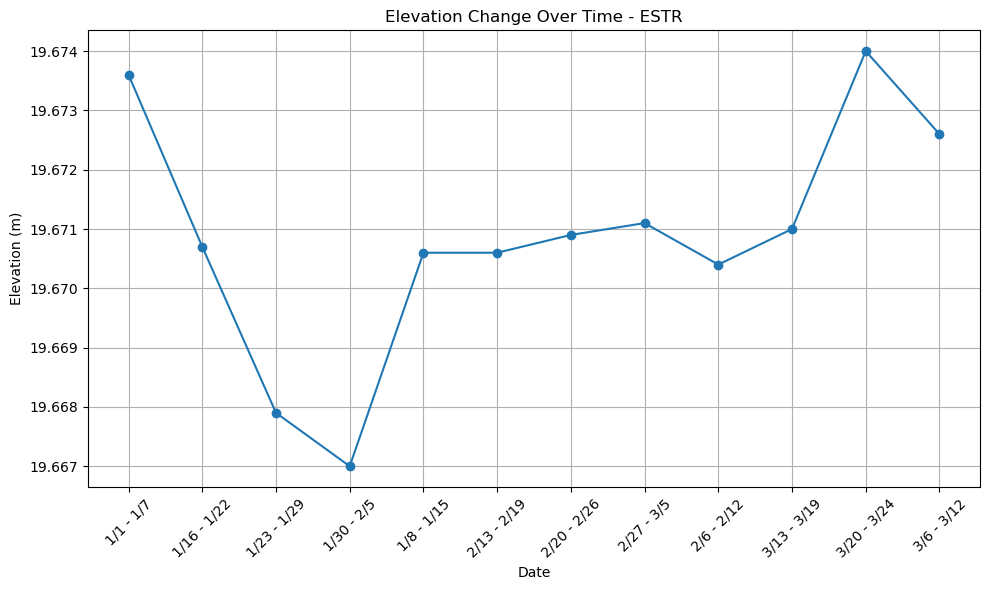

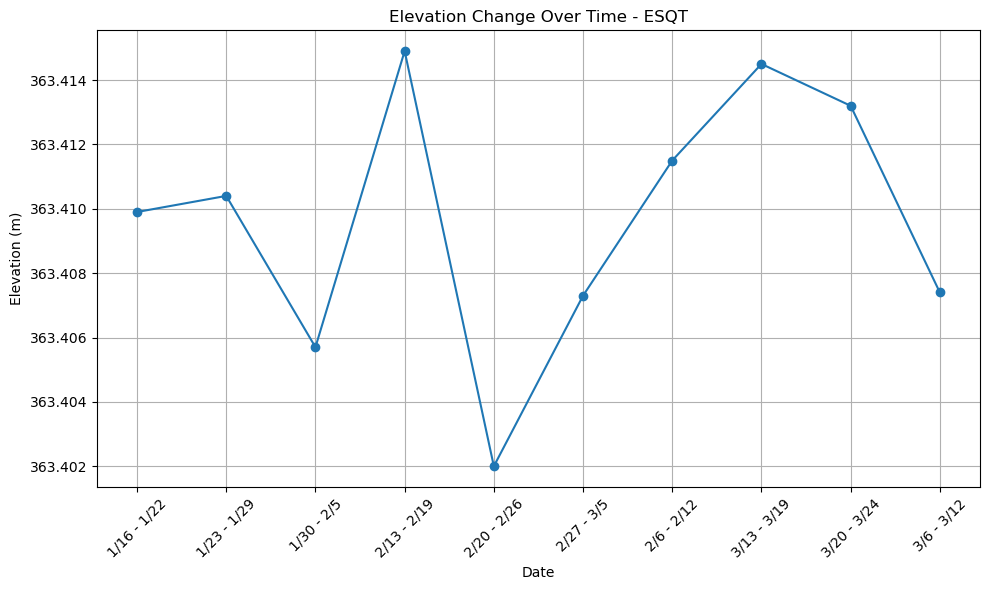

In [70]:
for code in codes:
    # Filter the DataFrame for the current code
    df_code = df[df['code'] == code]
    
    # Sort the DataFrame by date
    df_code = df_code.sort_values(by='date')
    
    # Create a line plot
    plt.figure(figsize=(10, 6))
    plt.plot(df_code['date'], df_code['hgt'], marker='o', linestyle='-')
    plt.title(f'Elevation Change Over Time - {code}')
    plt.xlabel('Date')
    plt.ylabel('Elevation (m)')
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # Ensure elevation is printed in meters with 3 decimal places
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


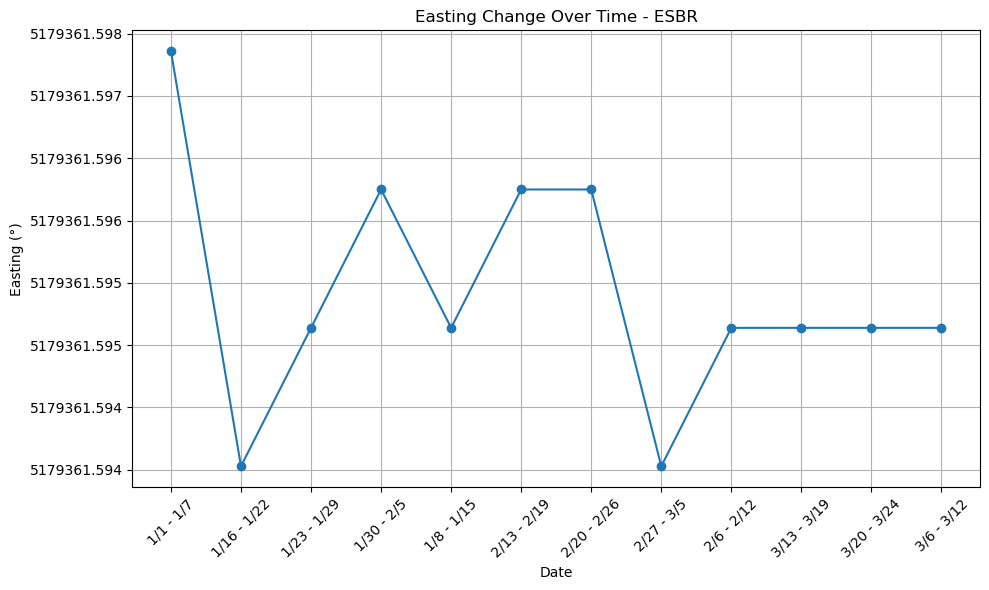

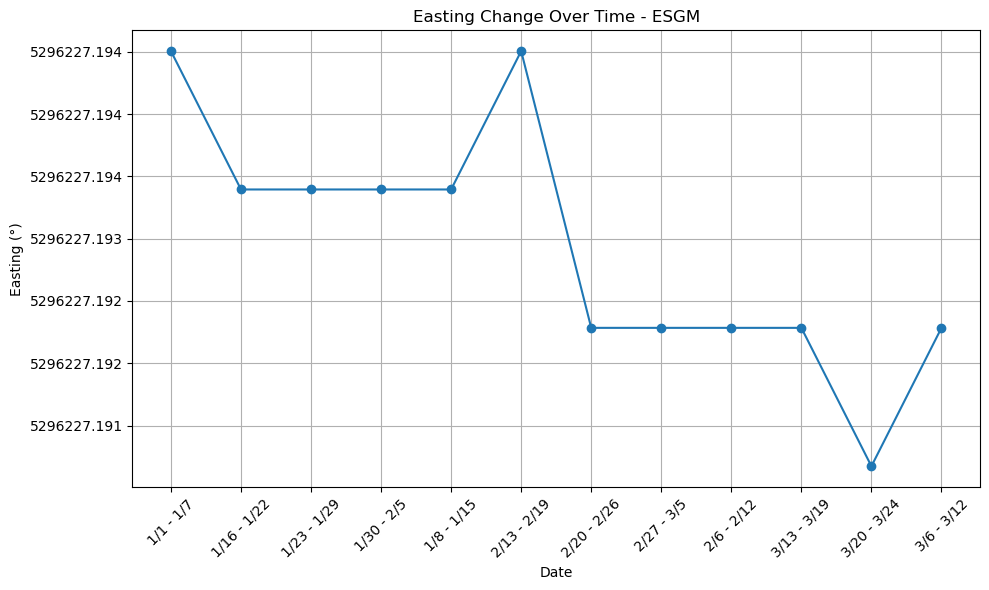

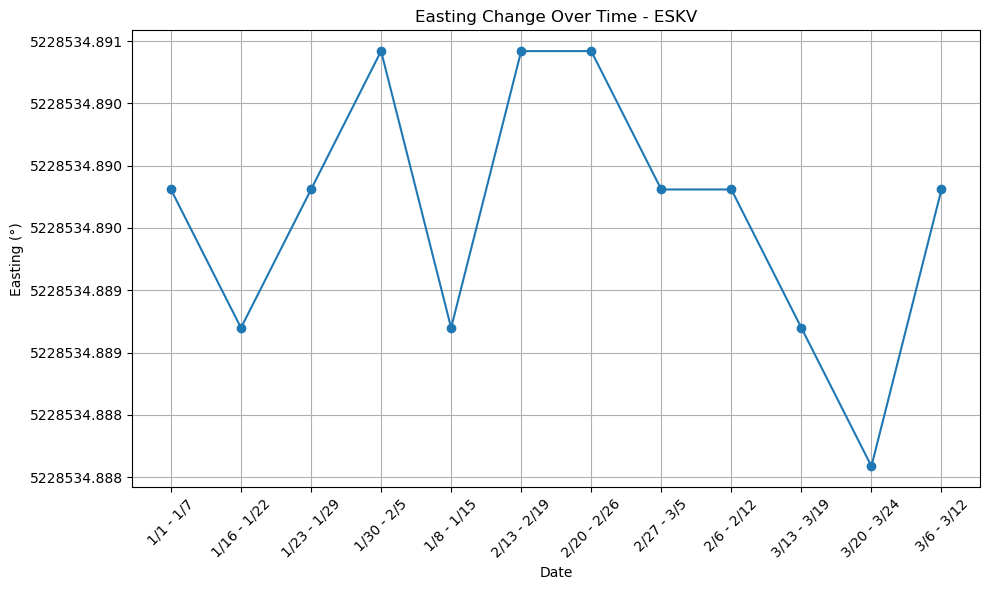

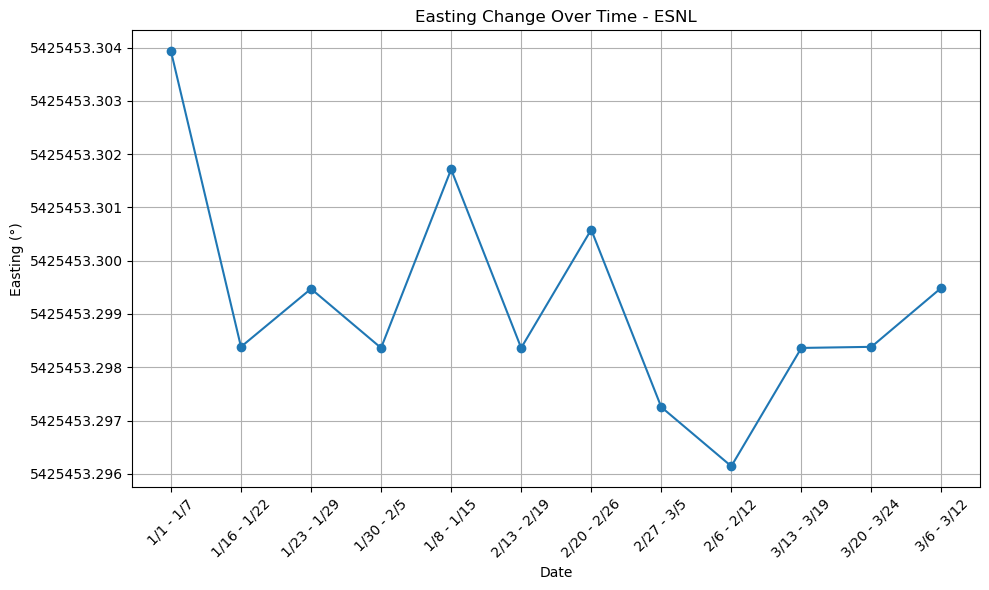

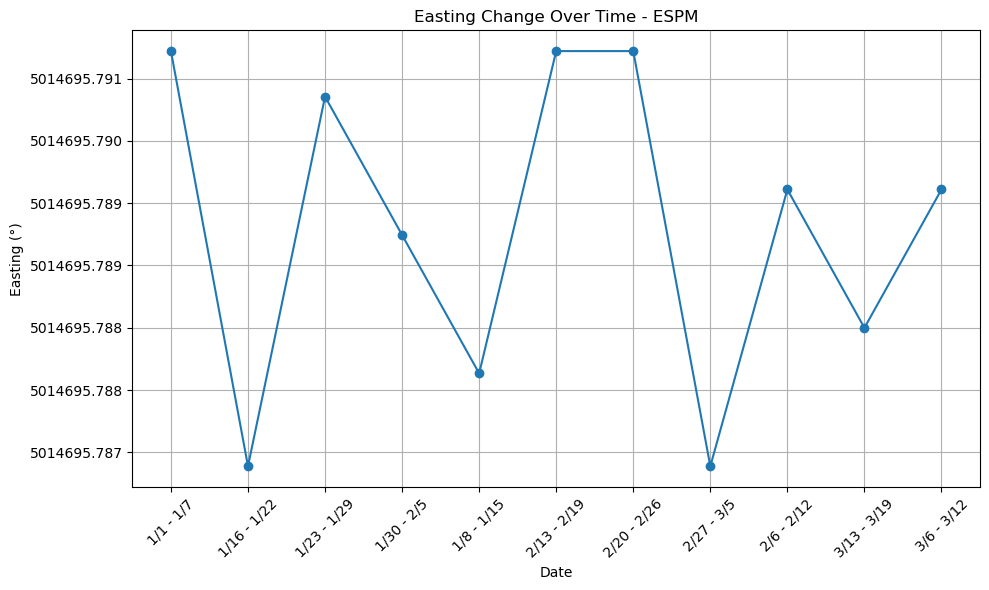

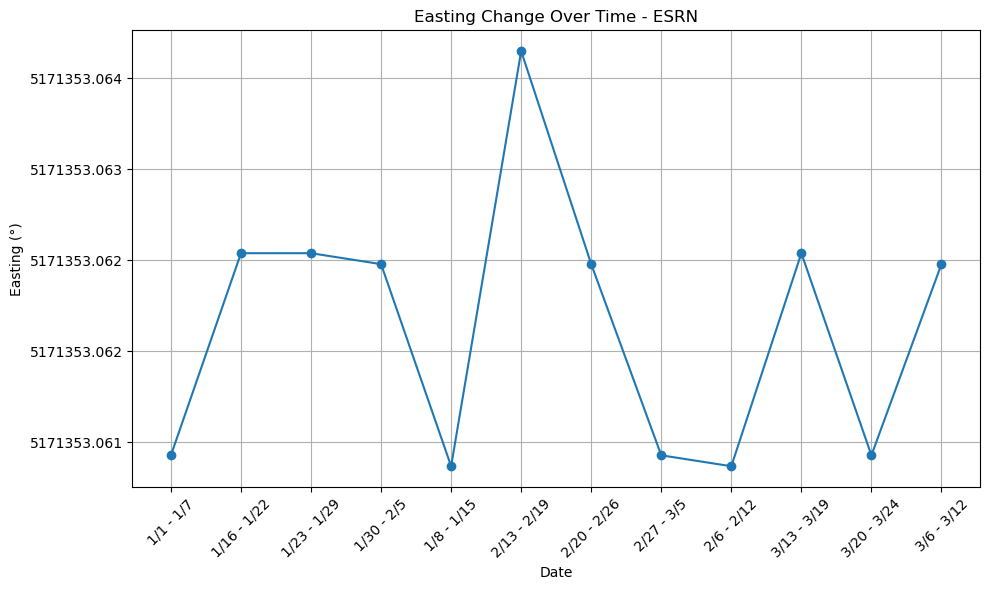

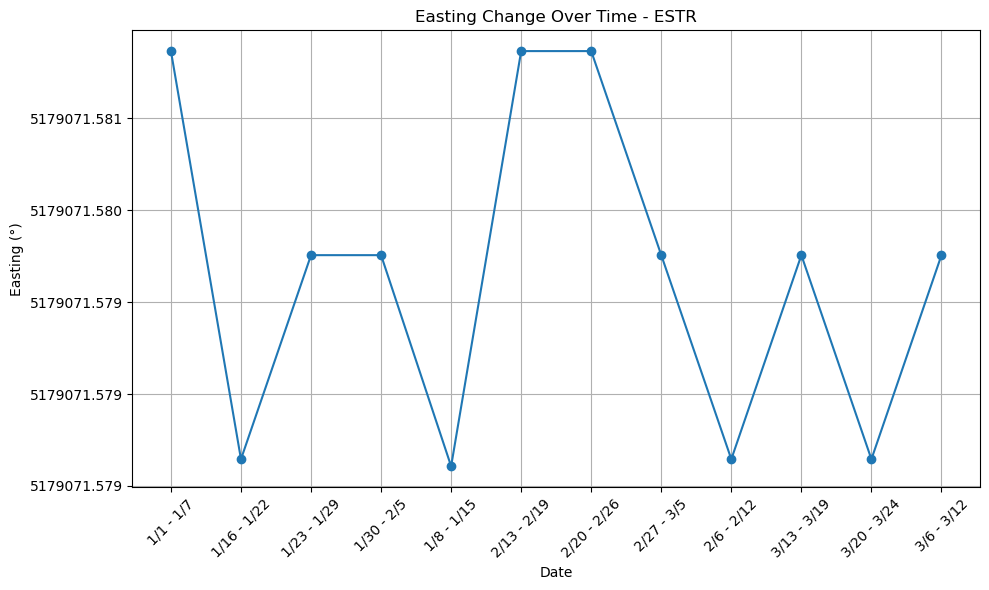

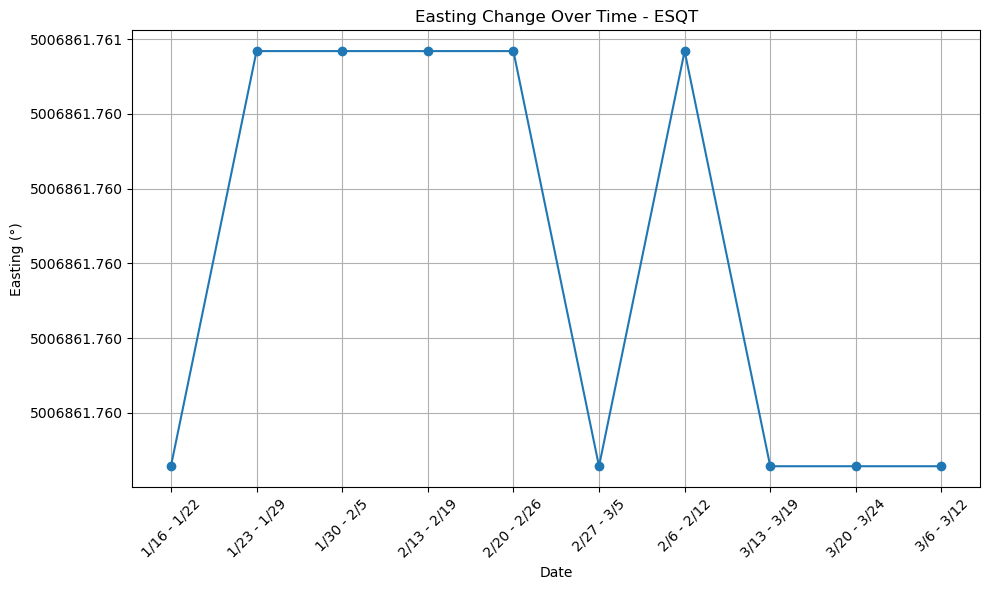

In [71]:
for code in codes:
    # Filter the DataFrame for the current code
    df_code = df[df['code'] == code]
    
    # Sort the DataFrame by date
    df_code = df_code.sort_values(by='date')
    
    # Create a line plot
    plt.figure(figsize=(10, 6))
    plt.plot(df_code['date'], df_code['lon_nztm'], marker='o', linestyle='-')
    plt.title(f'Easting Change Over Time - {code}')
    plt.xlabel('Date')
    plt.ylabel('Easting (\u00B0)')
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # Ensure elevation is printed in meters with 3 decimal places
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

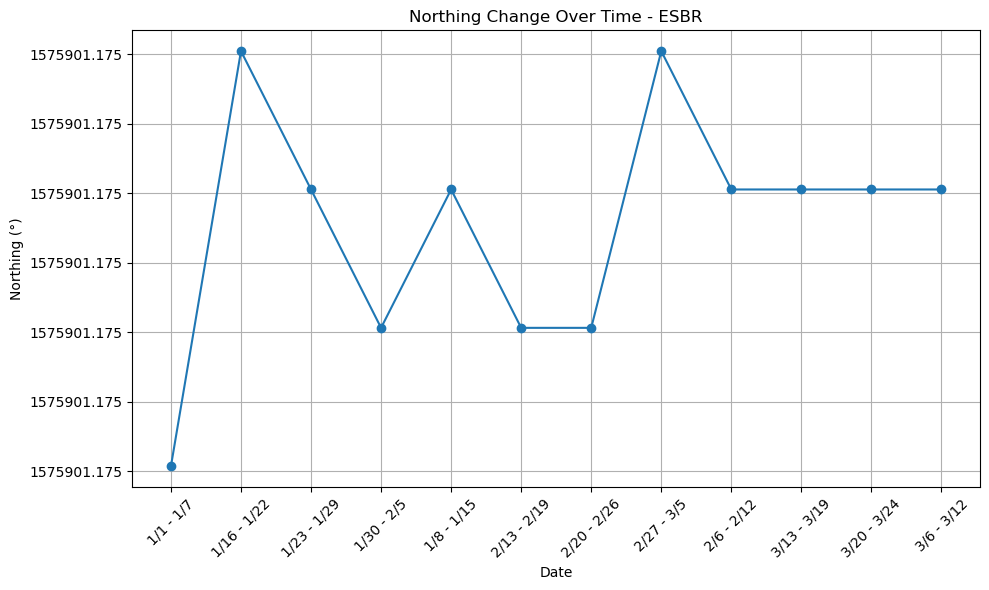

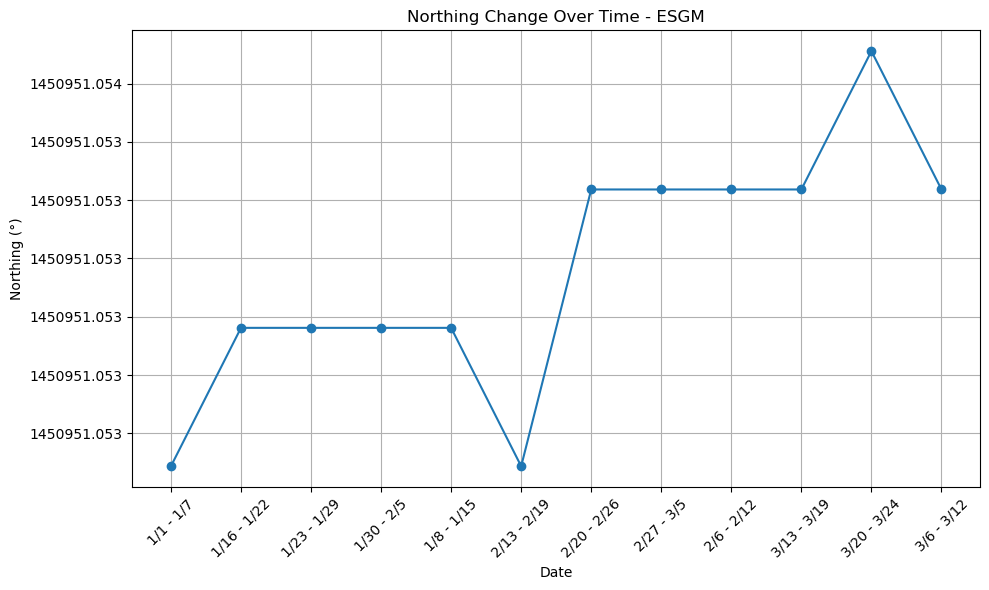

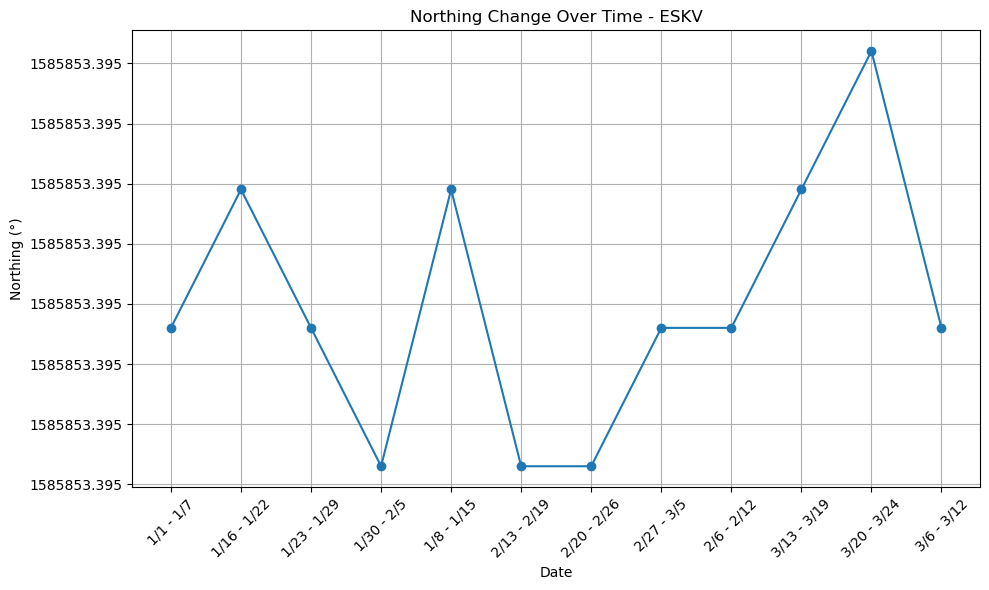

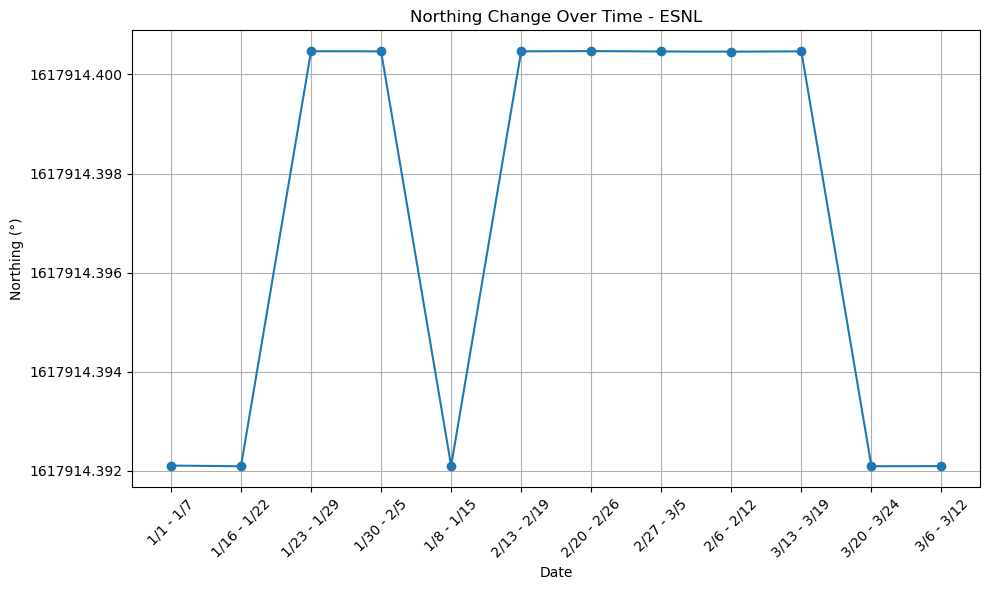

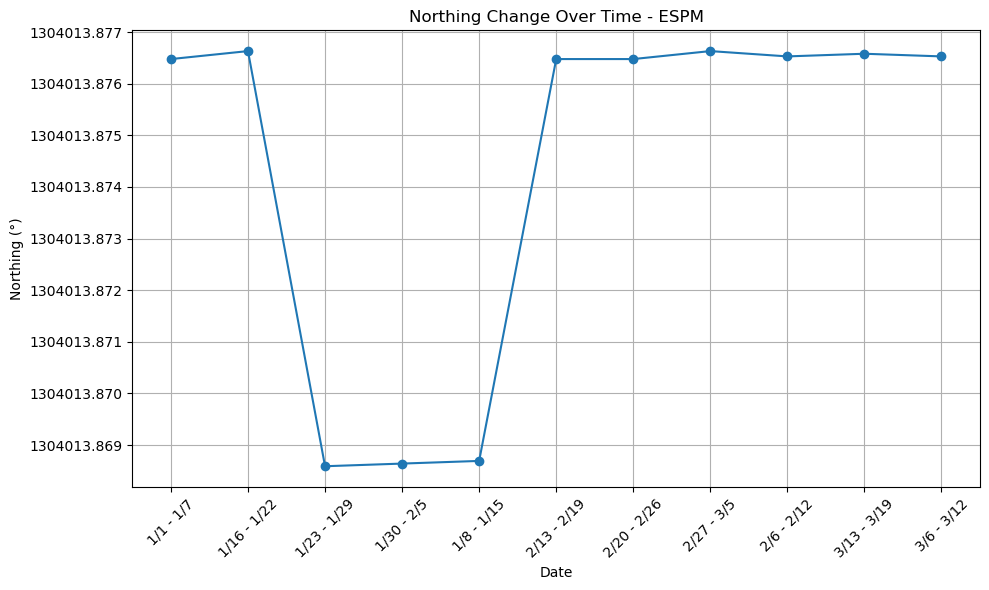

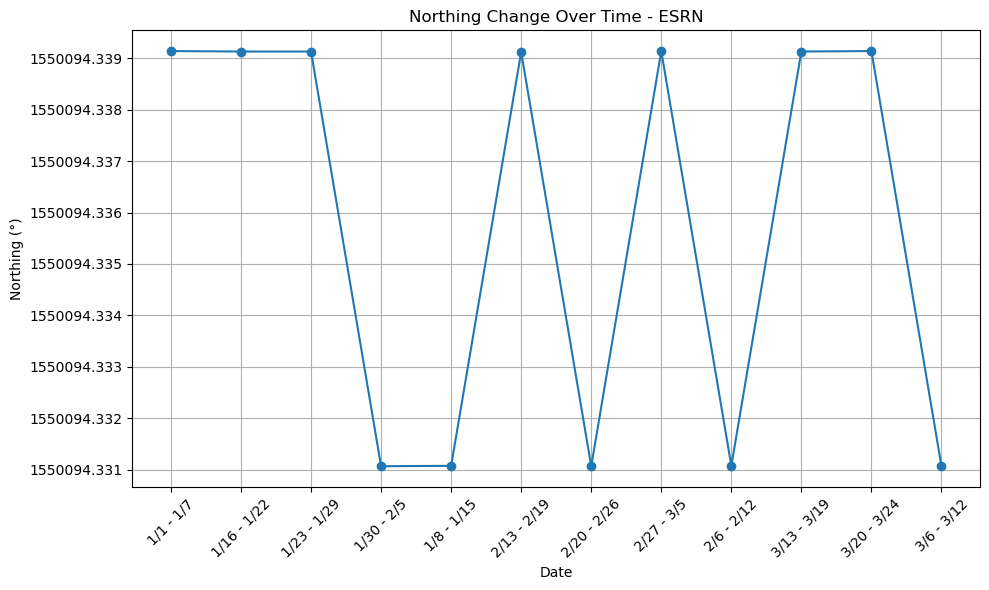

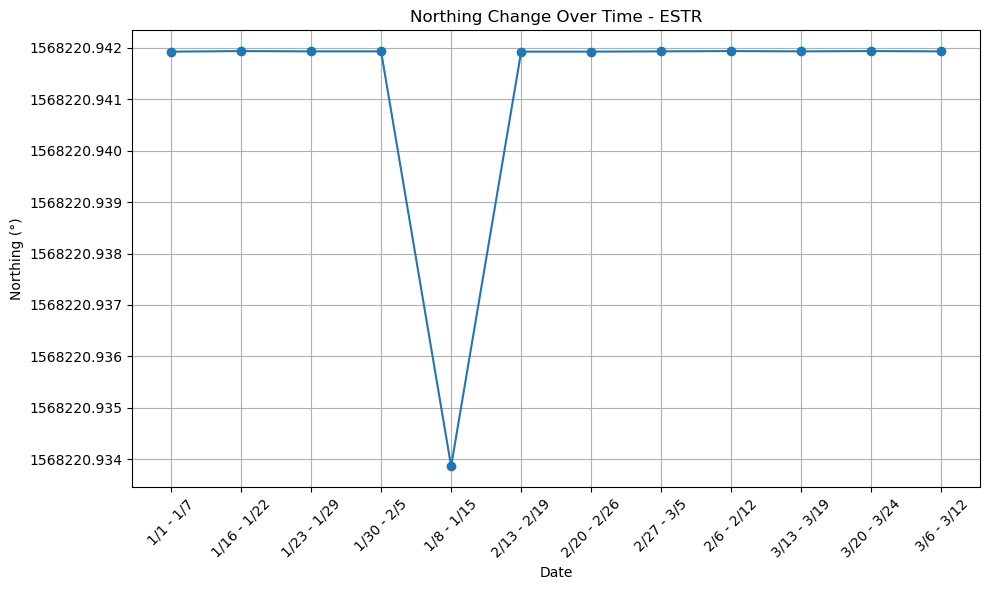

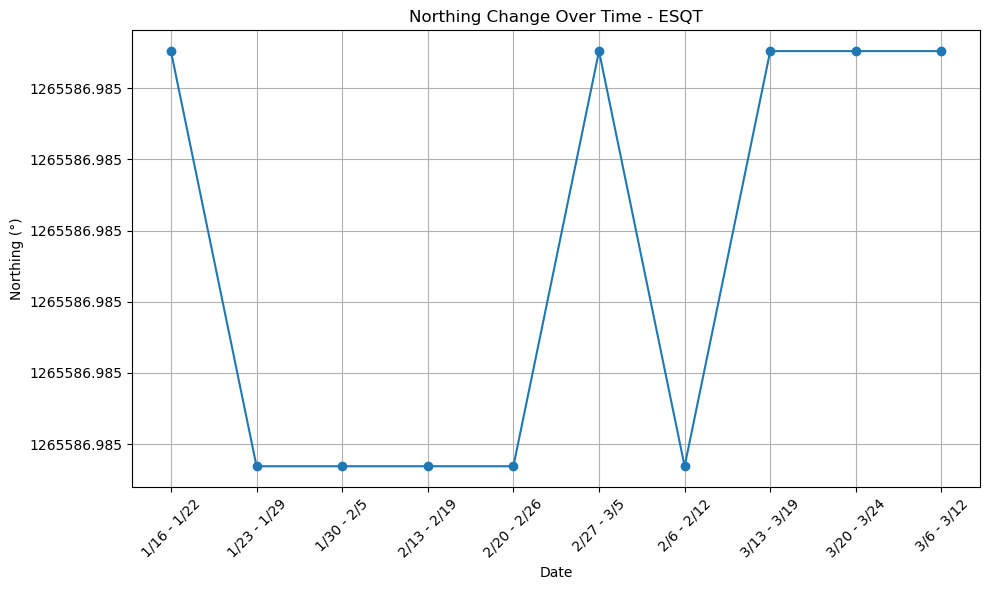

In [72]:
for code in codes:
    # Filter the DataFrame for the current code
    df_code = df[df['code'] == code]
    
    # Sort the DataFrame by date
    df_code = df_code.sort_values(by='date')
    
    # Create a line plot
    plt.figure(figsize=(10, 6))
    plt.plot(df_code['date'], df_code['lat_nztm'], marker='o', linestyle='-')
    plt.title(f'Northing Change Over Time - {code}')
    plt.xlabel('Date')
    plt.ylabel('Northing (\u00B0)')
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # Ensure elevation is printed in meters with 3 decimal places
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [73]:
codes = df['code'].unique()

In [74]:
def mean_ci(data):
    mean = np.mean(data)
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
    return mean, (ci[1] - mean)

In [75]:
for code in codes:
    df_code = df[df['code'] == code]
    
    lon_mean, lon_ci = mean_ci(df_code['lon_nztm'])
    lat_mean, lat_ci = mean_ci(df_code['lat_nztm'])
    hgt_mean, hgt_ci = mean_ci(df_code['hgt'])
    
    print(f"Code {code}:")
    print(f"  Longitude (NZTM2000): {lon_mean:.4f} +/- {lon_ci:.6f}")
    print(f"  Latitude (NZTM2000): {lat_mean:.4f} +/- {lat_ci:.6f}")
    print(f"  Height: {hgt_mean:.2f} +/- {hgt_ci:.4f}")
    print()


Code ESBR:
  Longitude (NZTM2000): 5179361.5954 +/- 0.000611
  Latitude (NZTM2000): 1575901.1751 +/- 0.000002
  Height: 11.06 +/- 0.0013

Code ESGM:
  Longitude (NZTM2000): 5296227.1929 +/- 0.000635
  Latitude (NZTM2000): 1450951.0535 +/- 0.000014
  Height: 14.28 +/- 0.0017

Code ESKV:
  Longitude (NZTM2000): 5228534.8896 +/- 0.000661
  Latitude (NZTM2000): 1585853.3954 +/- 0.000001
  Height: 299.44 +/- 0.0014

Code ESNL:
  Longitude (NZTM2000): 5425453.2992 +/- 0.001319
  Latitude (NZTM2000): 1617914.3970 +/- 0.002736
  Height: 14.03 +/- 0.0010

Code ESPM:
  Longitude (NZTM2000): 5014695.7893 +/- 0.000868
  Latitude (NZTM2000): 1304013.8744 +/- 0.002479
  Height: 220.26 +/- 0.0034

Code ESRN:
  Longitude (NZTM2000): 5171353.0621 +/- 0.000462
  Latitude (NZTM2000): 1550094.3358 +/- 0.002640
  Height: 50.71 +/- 0.0012

Code ESTR:
  Longitude (NZTM2000): 5179071.5797 +/- 0.000562
  Latitude (NZTM2000): 1568220.9413 +/- 0.001481
  Height: 19.67 +/- 0.0013

Code ESQT:
  Longitude (NZTM2000